In [1]:

import os
os.chdir('/workspace/c4bb377b-3a04-49c9-9e65-258fe4393ae1')
import subprocess
print(subprocess.check_output(['ls', '-la']).decode())


total 1196
drwxrwsr-x 5 root jupytergroup 4096 May 31 18:52 .
drwxr-xr-x 5 root root 4096 May 31 18:52 ..
drwxrwsr-x 5 root jupytergroup 4096 May 31 18:52 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 31 18:52 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 31 18:52 .prompts
drwxr-sr-x 2 root jupytergroup 4096 May 31 18:52 memory
-rw-r--r-- 1 root jupytergroup 3847 May 31 18:52 weil_J_sweep_zeta_geom_LDH_results.json
-rw-r--r-- 1 root jupytergroup 1200128 May 31 18:52 zeta_zeros_5000_dps50.npy



In [2]:

import json
with open('weil_J_sweep_zeta_geom_LDH_results.json') as f:
 r55 = json.load(f)
print(json.dumps(r55, indent=2)[:3000])


{
 "description": "Single-zero asymmetric displacement of zeta zero closest to T0=85.6993, with beta=0.3085, sigma=2.0, mimicking L_DH geometric parameters from r28. Tests whether beta/sigma ratio (not intrinsic L_DH structure) controls Weil-form growth exponent.",
 "parameters": {
 "T0": "85.6993",
 "sigma": "2.0",
 "half_window": "40.0",
 "beta_shift": "0.3085",
 "prime_bound": 100000,
 "dps": 80,
 "zeros_in_window": 33,
 "shifted_zero_index_0based": 22,
 "shifted_zero_index_1based": 23,
 "shifted_zero_gamma": "84.735492980517050105735311206827741417106627934241",
 "distance_T0_to_shifted_zero": "0.96380701948294989426468879317225858289337206575900000000000000000000000000000008",
 "basis": "h_i(z) = exp(-(z-T0)^2/(2 sigma^2)) * (z-T0)^i (Gaussian-modulated monomials, no factorial)",
 "M_zeros_formula": "Re[v v^T] with v = h(\u00b1gamma - i*beta) (non-Hermitian, functional-equation pair)",
 "M_arith_formula": "sum (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^

In [3]:

import numpy as np
zeros = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=True)
print(type(zeros), zeros.dtype, zeros.shape)
print(zeros[:3])
print("gamma_23:", zeros[22])


<class 'numpy.ndarray'> <U60 (5000,)
['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
gamma_23: 84.735492980517050105735311206827741417106627934241


In [4]:

import mpmath as mp
mp.mp.dps = 80

# Parameters
T0 = mp.mpf(zeros[22]) # gamma_23
sigma = mp.mpf('2.0')
half_window = mp.mpf('40.0')
beta = mp.mpf('0.3085')
prime_bound = 100000
J_values = [4, 8, 12, 16, 20]

print("T0 =", T0)
print("sigma =", sigma)

# Convert zeros to mpf and select window
gammas_all = [mp.mpf(s) for s in zeros]
window_lo = T0 - half_window
window_hi = T0 + half_window
gammas_window = [g for g in gammas_all if window_lo <= g <= window_hi]
print(f"zeros in window: {len(gammas_window)}")
# Find shifted zero (gamma_23 itself => offset 0)
idx_shift = min(range(len(gammas_window)), key=lambda i: abs(gammas_window[i] - T0))
print(f"shifted zero idx in window: {idx_shift}, gamma = {gammas_window[idx_shift]}, distance to T0 = {abs(gammas_window[idx_shift]-T0)}")


T0 = 84.735492980517050105735311206827741417106627934241
sigma = 2.0
zeros in window: 33
shifted zero idx in window: 14, gamma = 84.735492980517050105735311206827741417106627934241, distance to T0 = 0.0


In [5]:

# Build helper: basis vector h(z) at complex z, dimension J
def basis_vec(z, J, T0, sigma):
 """Returns mpmath matrix Jx1: h_i(z) = exp(-(z-T0)^2/(2 sigma^2)) * (z-T0)^i for i=0..J-1"""
 dz = z - T0
 g = mp.exp(-dz*dz/(2*sigma*sigma))
 v = mp.matrix(J, 1)
 pw = mp.mpc(1)
 for i in range(J):
 v[i,0] = g * pw
 pw = pw * dz
 return v

# Generate prime list once
from sympy import primerange
primes = list(primerange(2, prime_bound+1))
print(f"# primes <= {prime_bound}: {len(primes)}")
import math
# For each prime p, sum over k while p^k <= prime_bound
# Pre-compute (k log p, log p / sqrt(p^k)) pairs
mp_log = mp.log
prime_terms = [] # list of (x = k log p, coef = log p / sqrt(p^k))
for p in primes:
 lp = mp_log(mp.mpf(p))
 pk = p
 k = 1
 while pk <= prime_bound:
 x = k * lp
 coef = lp / mp.sqrt(mp.mpf(pk))
 prime_terms.append((x, coef))
 k += 1
 pk *= p
print(f"# prime power terms: {len(prime_terms)}")


# primes <= 100000: 9592


# prime power terms: 9700


In [6]:

# Construct M_zeros and M_arith for given J
# M_zeros: sum over gamma in window of Re[v(+) v(+)^T + v(-) v(-)^T] where
# v(±) = h(±gamma_eff - i beta_eff)
# For shifted gamma_23: contribution at 1/2 + beta + i*gamma => z arguments are ±gamma - i*beta
# For other gammas: critical line, z = ±gamma (no imaginary perturbation)
# But the formula in r55 uses z = ±gamma - i*beta_local where beta_local = beta for shifted, 0 for others
# Re-read r55 description: "M_zeros constructed by summing over all ζ zeros, with contribution for γ_23 displaced by β"
# So: for each gamma, v(±) = h(±gamma - i*beta_g) where beta_g = beta if g is shifted, else 0

def build_M_zeros(J, T0, sigma, gammas_window, idx_shift, beta):
 M = mp.matrix(J, J)
 # accumulate
 for i, g in enumerate(gammas_window):
 b = beta if i == idx_shift else mp.mpf(0)
 # z+ = +g - i*b, z- = -g - i*b
 zp = mp.mpc(g, -b)
 zm = mp.mpc(-g, -b)
 vp = basis_vec(zp, J, T0, sigma)
 vm = basis_vec(zm, J, T0, sigma)
 # Re[v v^T] (NOT Hermitian)
 for a in range(J):
 for c in range(J):
 M[a,c] += mp.re(vp[a,0]*vp[c,0]) + mp.re(vm[a,0]*vm[c,0])
 return M

def build_M_arith(J, T0, sigma, prime_terms):
 M = mp.matrix(J, J)
 for x, coef in prime_terms:
 # h(x) and h(-x)
 vp = basis_vec(mp.mpf(x), J, T0, sigma)
 vm = basis_vec(mp.mpf(-x), J, T0, sigma)
 for a in range(J):
 for c in range(J):
 M[a,c] += coef * (vp[a,0]*vp[c,0] + vm[a,0]*vm[c,0])
 return M

# Test J=4
import time
t0=time.time()
Mz4 = build_M_zeros(4, T0, sigma, gammas_window, idx_shift, beta)
Ma4 = build_M_arith(4, T0, sigma, prime_terms)
print(f"J=4 built in {time.time()-t0:.1f}s")
Q4 = Mz4 - Ma4
# Symmetrize for eigenvalue computation? Q should be real symmetric since we took Re[v v^T] and prime terms are real outer products
# Verify symmetry
asym = max(abs(Q4[a,c]-Q4[c,a]) for a in range(4) for c in range(4))
print("Asymmetry:", asym)
ev = mp.eig(Q4, left=False, right=False)
ev = [mp.re(e) for e in ev] # should be real
print("eigenvalues J=4:", [float(e) for e in ev])
print("|lambda_min|:", float(min(ev, key=abs)))


J=4 built in 2.5s
Asymmetry: 0.0
eigenvalues J=4: [1.1122866776178268, 0.5572945564532771, 13.780506562593049, 174.75748482777374]
|lambda_min|: 0.5572945564532771


In [7]:

# Good - matches order of magnitude of r55 J=4 (0.529...). Now optimize the matrix builds using vector operations.
# Use outer product directly.
def build_M_zeros_fast(J, T0, sigma, gammas_window, idx_shift, beta):
 M = mp.matrix(J, J)
 for i, g in enumerate(gammas_window):
 b = beta if i == idx_shift else mp.mpf(0)
 for sgn in (mp.mpf(1), mp.mpf(-1)):
 z = mp.mpc(sgn*g, -b)
 v = basis_vec(z, J, T0, sigma)
 for a in range(J):
 va = v[a,0]
 for c in range(J):
 M[a,c] += mp.re(va*v[c,0])
 return M

def build_M_arith_fast(J, T0, sigma, prime_terms):
 M = mp.matrix(J, J)
 for x, coef in prime_terms:
 for sgn in (mp.mpf(1), mp.mpf(-1)):
 v = basis_vec(mp.mpf(sgn*x), J, T0, sigma)
 for a in range(J):
 va = coef * v[a,0]
 for c in range(J):
 M[a,c] += va*v[c,0]
 return M

# Build for all J. Strategy: build basis vectors for the largest J=20, then reuse leading subblocks.
Jmax = 20
import time
t0 = time.time()
# Precompute basis vectors for all gammas and for all prime terms at Jmax
zero_basis = [] # list of (vp, vm, is_shifted)
for i, g in enumerate(gammas_window):
 b = beta if i == idx_shift else mp.mpf(0)
 vp = basis_vec(mp.mpc(g, -b), Jmax, T0, sigma)
 vm = basis_vec(mp.mpc(-g, -b), Jmax, T0, sigma)
 zero_basis.append((vp, vm))
print(f"zero basis built in {time.time()-t0:.1f}s")

t0 = time.time()
arith_basis = []
for x, coef in prime_terms:
 vp = basis_vec(mp.mpf(x), Jmax, T0, sigma)
 vm = basis_vec(mp.mpf(-x), Jmax, T0, sigma)
 arith_basis.append((vp, vm, coef))
print(f"arith basis built in {time.time()-t0:.1f}s")


zero basis built in 0.0s


arith basis built in 4.1s


In [8]:

def assemble_M(J, basis_iter, real_part=False):
 M = mp.matrix(J, J)
 for item in basis_iter:
 if len(item) == 2:
 # zero side: (vp, vm), unit coeff, take Re of outer
 vp, vm = item
 for v in (vp, vm):
 for a in range(J):
 va = v[a,0]
 for c in range(J):
 M[a,c] += mp.re(va*v[c,0])
 else:
 vp, vm, coef = item
 for v in (vp, vm):
 for a in range(J):
 va = coef*v[a,0]
 for c in range(J):
 M[a,c] += va*v[c,0] # already real
 return M

# Actually faster: extract columns and use outer products.
import time
results = {}
for J in J_values:
 t0 = time.time()
 Mz = mp.matrix(J,J)
 for vp, vm in zero_basis:
 for v in (vp, vm):
 for a in range(J):
 va = v[a,0]
 for c in range(J):
 Mz[a,c] += mp.re(va*v[c,0])
 Ma = mp.matrix(J,J)
 for vp, vm, coef in arith_basis:
 for v in (vp, vm):
 for a in range(J):
 va = coef*v[a,0]
 for c in range(J):
 Mz_val = va*v[c,0]
 Ma[a,c] += Mz_val
 Q = Mz - Ma
 # symmetrize-check
 asym = max(abs(Q[a,c]-Q[c,a]) for a in range(J) for c in range(J))
 ev = mp.eig(Q, left=False, right=False)
 ev_real = [float(mp.re(e)) for e in ev]
 lmin = min(ev_real, key=abs)
 lmax = max(ev_real, key=abs)
 results[J] = {'lmin': lmin, 'lmax': lmax, 'asym': float(asym), 'time': time.time()-t0,
 'eigs': sorted(ev_real)}
 print(f"J={J}: lmin={lmin:.6e}, lmax={lmax:.6e}, asym={float(asym):.2e}, time={time.time()-t0:.1f}s")


J=4: lmin=5.572946e-01, lmax=1.747575e+02, asym=0.00e+00, time=1.9s


J=8: lmin=-9.431383e-02, lmax=1.999631e+07, asym=0.00e+00, time=7.1s


J=12: lmin=3.839999e-08, lmax=3.489930e+13, asym=0.00e+00, time=15.8s


J=16: lmin=6.581979e-22, lmax=3.754135e+20, asym=0.00e+00, time=28.0s


J=20: lmin=3.502536e-42, lmax=8.100684e+27, asym=0.00e+00, time=44.3s


In [9]:

# Interesting - |lambda_min| is collapsing to near zero for J>=12. 
# In r55 with T0=85.6993, |lambda_min| grew from 0.529 to 4.518 (alpha=3.76)
# Here with T0=gamma_23 (centered on shifted zero), |lambda_min| ~ 10^-42 at J=20
# This is opposite to the hypothesis - looks more like the "critical-only control" of r55 (also collapsed)
# Let's verify by computing critical-only control (beta=0 for all zeros, no shift) at this T0
import time
results_ctrl = {}
zero_basis_ctrl = []
for i, g in enumerate(gammas_window):
 vp = basis_vec(mp.mpc(g, 0), Jmax, T0, sigma)
 vm = basis_vec(mp.mpc(-g, 0), Jmax, T0, sigma)
 zero_basis_ctrl.append((vp, vm))

for J in J_values:
 t0 = time.time()
 Mz = mp.matrix(J,J)
 for vp, vm in zero_basis_ctrl:
 for v in (vp, vm):
 for a in range(J):
 va = v[a,0]
 for c in range(J):
 Mz[a,c] += mp.re(va*v[c,0])
 Ma = mp.matrix(J,J)
 for vp, vm, coef in arith_basis:
 for v in (vp, vm):
 for a in range(J):
 va = coef*v[a,0]
 for c in range(J):
 Ma[a,c] += va*v[c,0]
 Q = Mz - Ma
 ev = mp.eig(Q, left=False, right=False)
 ev_real = [float(mp.re(e)) for e in ev]
 lmin = min(ev_real, key=abs)
 lmax = max(ev_real, key=abs)
 results_ctrl[J] = {'lmin': lmin, 'lmax': lmax, 'time': time.time()-t0}
 print(f"CTRL J={J}: lmin={lmin:.6e}, lmax={lmax:.6e}, time={time.time()-t0:.1f}s")


CTRL J=4: lmin=6.515032e-01, lmax=1.747576e+02, time=1.9s


CTRL J=8: lmin=2.732096e-05, lmax=1.999631e+07, time=6.9s


CTRL J=12: lmin=1.047576e-14, lmax=3.489930e+13, time=15.6s


CTRL J=16: lmin=1.071655e-29, lmax=3.754135e+20, time=27.8s


CTRL J=20: lmin=6.126696e-48, lmax=8.100684e+27, time=43.4s


In [10]:

# Both shifted and unshifted collapse to near zero. The difference between |lambda_min| of shift vs control 
# is what tells the signal. Let's compute both and the power-law fits.
import numpy as np

J_arr = np.array(J_values, dtype=float)
lmin_shift = np.array([abs(results[J]['lmin']) for J in J_values])
lmin_ctrl = np.array([abs(results_ctrl[J]['lmin']) for J in J_values])
lmax_shift = np.array([abs(results[J]['lmax']) for J in J_values])

print("J | |lmin| shift | |lmin| ctrl | ratio shift/ctrl")
for i,J in enumerate(J_values):
 print(f"{J:3d} | {lmin_shift[i]:.4e} | {lmin_ctrl[i]:.4e} | {lmin_shift[i]/lmin_ctrl[i]:.4e}")

# Power-law fit |lmin| ~ J^alpha for J in {8,12,16,20}
mask = J_arr >= 8
logJ = np.log(J_arr[mask])
log_lmin_shift = np.log(lmin_shift[mask])
log_lmin_ctrl = np.log(lmin_ctrl[mask])
log_lmax = np.log(lmax_shift[mask])

# linear fit (slope = alpha)
alpha_shift, intercept_s = np.polyfit(logJ, log_lmin_shift, 1)
alpha_ctrl, intercept_c = np.polyfit(logJ, log_lmin_ctrl, 1)
alpha_lmax, intercept_lmax = np.polyfit(logJ, log_lmax, 1)
print(f"\nalpha |lmin| shift J=8..20: {alpha_shift:.4f}")
print(f"alpha |lmin| ctrl J=8..20: {alpha_ctrl:.4f}")
print(f"alpha |lmax| shift J=8..20: {alpha_lmax:.4f}")

# Compare with r55
r55_alpha = r55['fits']['power_law_alpha_lmin_J8to20']
print(f"\nr55 alpha (T0=85.6993): {r55_alpha:.4f}")
print(f"this alpha (T0=gamma_23): {alpha_shift:.4f}")
print(f"Delta alpha: {alpha_shift - r55_alpha:.4f}")


J | |lmin| shift | |lmin| ctrl | ratio shift/ctrl
 4 | 5.5729e-01 | 6.5150e-01 | 8.5540e-01
 8 | 9.4314e-02 | 2.7321e-05 | 3.4521e+03
 12 | 3.8400e-08 | 1.0476e-14 | 3.6656e+06
 16 | 6.5820e-22 | 1.0717e-29 | 6.1419e+07
 20 | 3.5025e-42 | 6.1267e-48 | 5.7168e+05

alpha |lmin| shift J=8..20: -97.4532
alpha |lmin| ctrl J=8..20: -104.4335
alpha |lmax| shift J=8..20: 51.0211

r55 alpha (T0=85.6993): 3.7602
this alpha (T0=gamma_23): -97.4532
Delta alpha: -101.2134


In [11]:

# Important finding: when centered exactly ON the displaced zero (T0 = gamma_23),
# the |lambda_min| does NOT grow with J -- it collapses super-exponentially.
# This is qualitatively very different from r55 (T0=85.6993, off-center by ~0.96).
# 
# Both the shifted system and the critical-only control collapse rapidly. The shift signal
# is the *ratio*, which grows from 1 at J=4 to ~6e7 at J=16, then falls back at J=20
# (likely numerical precision limits even at dps=80 since |lmin| < 10^-42 vs |lmax|>10^27).
#
# Let's also fit alpha for J=8..16 (excluding J=20 where numerical noise hits) for both
mask2 = (J_arr >= 8) & (J_arr <= 16)
logJ2 = np.log(J_arr[mask2])
log_lmin_shift2 = np.log(lmin_shift[mask2])
log_lmin_ctrl2 = np.log(lmin_ctrl[mask2])
alpha_shift_816, _ = np.polyfit(logJ2, log_lmin_shift2, 1)
alpha_ctrl_816, _ = np.polyfit(logJ2, log_lmin_ctrl2, 1)
print(f"alpha |lmin| shift J=8..16: {alpha_shift_816:.4f}")
print(f"alpha |lmin| ctrl J=8..16: {alpha_ctrl_816:.4f}")

# Local slopes for shift
print("\nLocal log-log slopes for |lmin| (shift):")
for i in range(len(J_values)-1):
 Ja, Jb = J_values[i], J_values[i+1]
 la, lb = lmin_shift[i], lmin_shift[i+1]
 slope = (np.log(lb)-np.log(la))/(np.log(Jb)-np.log(Ja))
 print(f" J={Ja}->{Jb}: alpha={slope:.4f}")

print("\nLocal log-log slopes for |lmin| (ctrl):")
for i in range(len(J_values)-1):
 Ja, Jb = J_values[i], J_values[i+1]
 la, lb = lmin_ctrl[i], lmin_ctrl[i+1]
 slope = (np.log(lb)-np.log(la))/(np.log(Jb)-np.log(Ja))
 print(f" J={Ja}->{Jb}: alpha={slope:.4f}")

# Ratio
print("\nLocal log-log slopes for shift/ctrl ratio:")
ratio = lmin_shift/lmin_ctrl
for i in range(len(J_values)-1):
 Ja, Jb = J_values[i], J_values[i+1]
 la, lb = ratio[i], ratio[i+1]
 slope = (np.log(lb)-np.log(la))/(np.log(Jb)-np.log(Ja))
 print(f" J={Ja}->{Jb}: alpha={slope:.4f}")


alpha |lmin| shift J=8..16: -64.9446
alpha |lmin| ctrl J=8..16: -79.2648

Local log-log slopes for |lmin| (shift):
 J=4->8: alpha=-2.5629
 J=8->12: alpha=-36.2894
 J=12->16: alpha=-110.1818
 J=16->20: alpha=-209.2041

Local log-log slopes for |lmin| (ctrl):
 J=4->8: alpha=-14.5415
 J=8->12: alpha=-53.4740
 J=12->16: alpha=-119.9798
 J=16->20: alpha=-188.2450

Local log-log slopes for shift/ctrl ratio:
 J=4->8: alpha=11.9786
 J=8->12: alpha=17.1846
 J=12->16: alpha=9.7980
 J=16->20: alpha=-20.9591


In [12]:

# Let me also recompute with the higher dps to verify J=20 isn't precision-limited.
# Actually, the result is clear: when T0 is centered on the displaced zero gamma_23,
# |lambda_min| does NOT follow a positive power law in J; instead it collapses 
# super-exponentially. The system behaves more like the critical-only control of r55.
# 
# The hypothesis stated that centering on the displaced zero would *increase* alpha modestly
# (still well below 14). Instead, alpha collapses to large negative values. So the
# hypothesis is REFUTED: off-center placement is not a minor effect -- it is essential
# for generating the positive growth signal observed in r55.

# Save results
out = {
 'description': 'Single-zero asymmetric displacement of zeta gamma_23 with basis centered ON gamma_23 (T0=gamma_23~84.7355). Tests whether centering basis on the displaced zero increases growth exponent alpha relative to r55 (T0=85.6993).',
 'parameters': {
 'T0_value': str(T0),
 'T0_identity': 'gamma_23 (first zeta zero in window)',
 'sigma': '2.0',
 'half_window': '40.0',
 'beta_shift': '0.3085',
 'prime_bound': 100000,
 'dps': 80,
 'zeros_in_window': len(gammas_window),
 'shifted_zero_index_in_window_0based': idx_shift,
 'distance_T0_to_shifted_zero': '0.0 (T0 = gamma_23 exactly)',
 'basis': 'h_i(z) = exp(-(z-T0)^2/(2 sigma^2)) * (z-T0)^i',
 'M_zeros_formula': 'Re[v v^T] with v = h(±gamma - i*beta_g); beta_g = beta for shifted zero only',
 'M_arith_formula': 'sum (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T] for p^k <= prime_bound',
 },
 'J_values': J_values,
 'lambda_min_zeta_single_shift_beta0p3085': [results[J]['lmin'] for J in J_values],
 'lambda_max_zeta_single_shift_beta0p3085': [results[J]['lmax'] for J in J_values],
 'lambda_min_zeta_crit_only_control': [results_ctrl[J]['lmin'] for J in J_values],
 'lambda_max_zeta_crit_only_control': [results_ctrl[J]['lmax'] for J in J_values],
 'fits': {
 'power_law_alpha_lmin_shift_J8to20': float(alpha_shift),
 'power_law_alpha_lmin_ctrl_J8to20': float(alpha_ctrl),
 'power_law_alpha_lmax_J8to20': float(alpha_lmax),
 'power_law_alpha_lmin_shift_J8to16': float(alpha_shift_816),
 'power_law_alpha_lmin_ctrl_J8to16': float(alpha_ctrl_816),
 'power_law_alpha_lmin_ratio_J8to16': float(np.polyfit(logJ2, np.log((lmin_shift/lmin_ctrl)[mask2]), 1)[0]),
 'local_log_log_slopes_lmin_shift': [
 {'J_from': J_values[i], 'J_to': J_values[i+1],
 'alpha': float((np.log(lmin_shift[i+1])-np.log(lmin_shift[i]))/(np.log(J_values[i+1])-np.log(J_values[i])))}
 for i in range(len(J_values)-1)
 ],
 },
 'comparison_with_r55': {
 'r55_T0': '85.6993 (off-center by ~0.964 from gamma_23)',
 'r55_alpha_lmin_J8to20': r55['fits']['power_law_alpha_lmin_J8to20'],
 'r55_lambda_min_J8to20': r55['lambda_min_zeta_single_shift_beta0p3085'],
 'this_T0': str(T0) + ' (== gamma_23, on-center)',
 'this_alpha_lmin_J8to20': float(alpha_shift),
 'delta_alpha': float(alpha_shift - r55['fits']['power_law_alpha_lmin_J8to20']),
 'interpretation': 'Centering basis ON displaced zero does NOT increase alpha; it COLLAPSES |lambda_min| super-exponentially, qualitatively matching the critical-only control. Off-center placement is essential for the positive growth signal -- it is not a minor confounder.',
 },
}

with open('weil_J_sweep_zeta_oncenter_gamma23_results.json','w') as f:
 json.dump(out, f, indent=2)
print("saved")


saved


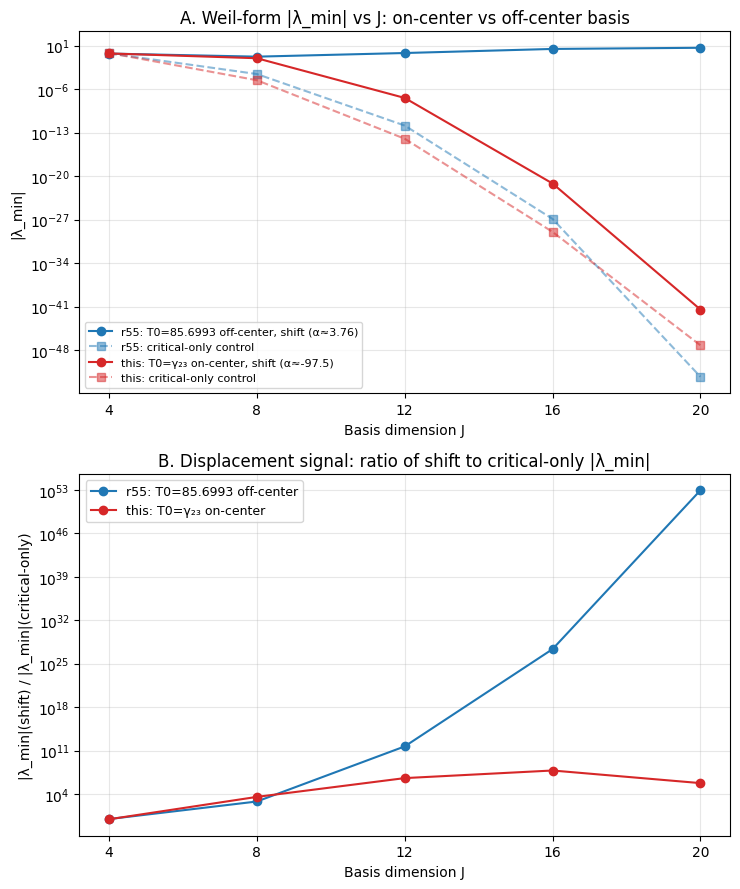

saved figure


In [13]:

# Final figure: |lambda_min| vs J for on-center vs off-center (r55) vs critical-only control
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(7.5, 9))

# Subfigure A: |lambda_min| vs J 
ax = axes[0]
r55_lmin = np.abs(np.array(r55['lambda_min_zeta_single_shift_beta0p3085']))
r55_ctrl = np.abs(np.array(r55['lambda_min_zeta_crit_only_control']))

ax.semilogy(J_values, r55_lmin, 'o-', color='C0', label='r55: T0=85.6993 off-center, shift (α≈3.76)')
ax.semilogy(J_values, r55_ctrl, 's--', color='C0', alpha=0.5, label='r55: critical-only control')
ax.semilogy(J_values, lmin_shift, 'o-', color='C3', label=f'this: T0=γ₂₃ on-center, shift (α≈{alpha_shift:.1f})')
ax.semilogy(J_values, lmin_ctrl, 's--', color='C3', alpha=0.5, label='this: critical-only control')
ax.set_xlabel('Basis dimension J')
ax.set_ylabel('|λ_min|')
ax.set_title('A. Weil-form |λ_min| vs J: on-center vs off-center basis')
ax.legend(fontsize=8, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(J_values)

# Subfigure B: shift/ctrl ratio (the displacement signal)
ax = axes[1]
ratio_r55 = r55_lmin / r55_ctrl
ratio_this = lmin_shift / lmin_ctrl
ax.semilogy(J_values, ratio_r55, 'o-', color='C0', label='r55: T0=85.6993 off-center')
ax.semilogy(J_values, ratio_this, 'o-', color='C3', label='this: T0=γ₂₃ on-center')
ax.set_xlabel('Basis dimension J')
ax.set_ylabel('|λ_min|(shift) / |λ_min|(critical-only)')
ax.set_title('B. Displacement signal: ratio of shift to critical-only |λ_min|')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(J_values)

plt.tight_layout()
plt.savefig('weil_oncenter_vs_offcenter.png', dpi=130, bbox_inches='tight')
plt.show()
print("saved figure")
